# MobileNetV2 Transfer Learning for Wafer Map Classification

This notebook evaluates ImageNet transfer learning on the same nine-class wafer-map task used by the custom CNN experiments.

It reuses the exact training, validation, and test indices produced by the full CNN notebook. The training partition remains capped at 3,000 samples per class, while validation and test keep their natural class distributions. Model selection is based on validation Macro F1, and the test set is evaluated only after the configuration has been fixed.

In [1]:
import os

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [2]:
import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [ ]:
def find_repository_root(start_path=None):
    current_path = (
        Path.cwd()
        if start_path is None
        else Path(start_path)
    ).resolve()

    for candidate in (current_path, *current_path.parents):
        if (
            (candidate / "project").is_dir()
            and (candidate / "datasets").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Repository root not found. Expected 'project' and "
        "'datasets' directories in the same location."
    )


REPO_ROOT = find_repository_root()
PROJECT_DIR = REPO_ROOT / "project"
DATASETS_DIR = REPO_ROOT / "datasets"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from utils import (
    clean_nested_columns,
    evaluate_classifier,
    make_macro_f1_callbacks,
    plot_confusion_matrix,
    plot_training_history,
    resize_wafer_maps,
    set_global_determinism,
)

print(f"Repository root: {REPO_ROOT}")

## Configuration

The notebook uses the split created by the full CNN experiment. MobileNetV2 receives 56×56 three-channel inputs derived from the original single-channel wafer maps.

In [4]:
DATASET_PATH = DATASETS_DIR / "Dataset.pkl"

REFERENCE_OUTPUT_DIR = PROJECT_DIR / "cnn_outputs"
SPLIT_PATH = REFERENCE_OUTPUT_DIR / "split_indices.npz"
REFERENCE_AUDIT_PATH = (
    REFERENCE_OUTPUT_DIR
    / "audit"
    / "full_audit.json"
)

OUTPUT_DIR = PROJECT_DIR / "cnn_outputs_mobilenetv2"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
AUDIT_DIR = OUTPUT_DIR / "audit"

TARGET_SHAPE = (56, 56)
MAX_SAMPLES_PER_CLASS = 3000

BATCH_SIZE = 128
PREDICTION_BATCH_SIZE = 256

FROZEN_EPOCHS = 20
FINE_TUNE_EPOCHS = 30

HEAD_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_LAYERS = 30

MOBILENET_WEIGHTS = "imagenet"

EXPECTED_CLASSES = [
    "center",
    "donut",
    "edge-loc",
    "edge-ring",
    "loc",
    "near-full",
    "none",
    "random",
    "scratch",
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], "GPU")
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as error:
        print(f"GPU configuration was already initialized: {error}")
else:
    print("No GPU detected. TensorFlow will use the CPU.")

set_global_determinism(SEED, clear_session=False)

Using GPU: /physical_device:GPU:0


## Dataset and fixed partitions

The dataset order must match the one used when the reference split was created. When the full audit is available, its dataset hash and split hashes are checked before training.

In [6]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_PATH}"
    )

if not SPLIT_PATH.exists():
    raise FileNotFoundError(
        "Reference split not found. Run the full CNN notebook first: "
        f"{SPLIT_PATH}"
    )

df = pd.read_pickle(DATASET_PATH)
df = clean_nested_columns(df)

required_columns = {"waferMap", "failureType"}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

df = df[
    df["failureType"].isin(EXPECTED_CLASSES)
].reset_index(drop=True)

missing_classes = sorted(
    set(EXPECTED_CLASSES).difference(
        df["failureType"].unique()
    )
)

if missing_classes:
    raise ValueError(
        f"Dataset is missing expected classes: {missing_classes}"
    )

print(f"Labeled wafer maps: {len(df):,}")
display(df.head())

Labeled wafer maps: 172,950


,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,training,none


In [7]:
encoder = LabelEncoder()
y_all = encoder.fit_transform(df["failureType"])

class_names = encoder.classes_
num_classes = len(class_names)

split_data = np.load(SPLIT_PATH)

required_split_keys = {
    "train_pool_indices",
    "train_indices",
    "validation_indices",
    "test_indices",
}

missing_split_keys = required_split_keys.difference(
    split_data.files
)

if missing_split_keys:
    raise KeyError(
        f"Missing split arrays: {sorted(missing_split_keys)}"
    )

train_pool_indices = split_data["train_pool_indices"]
train_indices = split_data["train_indices"]
validation_indices = split_data["validation_indices"]
test_indices = split_data["test_indices"]

all_split_indices = np.concatenate(
    [
        train_indices,
        validation_indices,
        test_indices,
    ]
)

if all_split_indices.min() < 0 or all_split_indices.max() >= len(df):
    raise IndexError(
        "Split indices are incompatible with the current dataset."
    )

assert len(np.intersect1d(train_indices, validation_indices)) == 0
assert len(np.intersect1d(train_indices, test_indices)) == 0
assert len(np.intersect1d(validation_indices, test_indices)) == 0
assert set(train_indices).issubset(set(train_pool_indices))

training_counts = np.bincount(
    y_all[train_indices],
    minlength=num_classes,
)

if training_counts.max() > MAX_SAMPLES_PER_CLASS:
    raise AssertionError(
        "The reference training split exceeds the 3,000-sample cap."
    )

print(f"Training pool before cap: {len(train_pool_indices):,}")
print(f"Training set after cap:   {len(train_indices):,}")
print(f"Validation set:           {len(validation_indices):,}")
print(f"Large test set:           {len(test_indices):,}")

Training pool before cap: 112,417
Training set after cap:   15,923
Validation set:           25,943
Large test set:           34,590


In [8]:
def distribution_for(indices, column_name):
    counts = np.bincount(
        y_all[indices],
        minlength=num_classes,
    )
    return pd.Series(
        counts,
        index=class_names,
        name=column_name,
    )


split_distribution = pd.concat(
    [
        distribution_for(
            train_pool_indices,
            "Training pool",
        ),
        distribution_for(
            train_indices,
            "Training after cap",
        ),
        distribution_for(
            validation_indices,
            "Validation",
        ),
        distribution_for(
            test_indices,
            "Large test",
        ),
    ],
    axis=1,
)

display(split_distribution)

,Training pool,Training after cap,Validation,Large test
center,2791,2791,644,859
donut,361,361,83,111
edge-loc,3372,3000,779,1038
edge-ring,6292,3000,1452,1936
loc,2336,2336,539,718
near-full,97,97,22,30
none,95830,3000,22115,29486
random,563,563,130,173
scratch,775,775,179,239


In [9]:
def sha256_array(array):
    array = np.ascontiguousarray(array)

    digest = hashlib.sha256()
    digest.update(str(array.dtype).encode("utf-8"))
    digest.update(str(array.shape).encode("utf-8"))
    digest.update(array.tobytes())

    return digest.hexdigest()


def sha256_file(path, chunk_size=8 * 1024 * 1024):
    path = Path(path)

    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


dataset_sha256 = sha256_file(DATASET_PATH)

if REFERENCE_AUDIT_PATH.exists():
    with REFERENCE_AUDIT_PATH.open(
        "r",
        encoding="utf-8",
    ) as file:
        reference_audit = json.load(file)

    consistency_checks = {
        "Dataset content": (
            dataset_sha256
            == reference_audit["dataset"]["sha256"]
        ),
        "Training indices": (
            sha256_array(train_indices)
            == reference_audit["splits"]["train"]["sha256"]
        ),
        "Validation indices": (
            sha256_array(validation_indices)
            == reference_audit[
                "splits"
            ]["validation"]["sha256"]
        ),
        "Test indices": (
            sha256_array(test_indices)
            == reference_audit["splits"]["test"]["sha256"]
        ),
    }

    display(
        pd.DataFrame(
            consistency_checks.items(),
            columns=["Check", "Passed"],
        )
    )

    if not all(consistency_checks.values()):
        raise AssertionError(
            "The MobileNetV2 experiment does not match "
            "the reference CNN dataset or partitions."
        )
else:
    print(
        "Reference audit not found. Split bounds and class caps "
        "were checked, but dataset hashes were not compared."
    )

,Check,Passed
0,Dataset content,True
1,Training indices,True
2,Validation indices,True
3,Test indices,True


## Resizing

Nearest-neighbor interpolation preserves the discrete wafer-map states. The arrays remain single-channel unsigned integers with values 0, 1, and 2.

In [10]:
X_train = resize_wafer_maps(
    df.iloc[train_indices],
    target_shape=TARGET_SHAPE,
)

X_validation = resize_wafer_maps(
    df.iloc[validation_indices],
    target_shape=TARGET_SHAPE,
)

X_test = resize_wafer_maps(
    df.iloc[test_indices],
    target_shape=TARGET_SHAPE,
)

y_train = y_all[train_indices]
y_validation = y_all[validation_indices]
y_test = y_all[test_indices]

y_train_categorical = to_categorical(
    y_train,
    num_classes=num_classes,
)

y_validation_categorical = to_categorical(
    y_validation,
    num_classes=num_classes,
)

print(f"Training features:   {X_train.shape}, {X_train.dtype}")
print(f"Validation features: {X_validation.shape}, {X_validation.dtype}")
print(f"Test features:       {X_test.shape}, {X_test.dtype}")
print(f"Observed pixel values: {np.unique(X_train)}")

if not np.array_equal(
    np.unique(X_train),
    np.array([0, 1, 2], dtype=np.uint8),
):
    raise ValueError(
        "Unexpected pixel values after nearest-neighbor resizing."
    )

Resizing 15,923 wafer maps to (56, 56)...


  0%|          | 0/15923 [00:00<?, ?it/s]

Resizing 25,943 wafer maps to (56, 56)...


  0%|          | 0/25943 [00:00<?, ?it/s]

Resizing 34,590 wafer maps to (56, 56)...


  0%|          | 0/34590 [00:00<?, ?it/s]

Training features:   (15923, 56, 56, 1), uint8
Validation features: (25943, 56, 56, 1), uint8
Test features:       (34590, 56, 56, 1), uint8
Observed pixel values: [0 1 2]


## MobileNetV2 model

The original wafer states 0, 1, and 2 are mapped to −1, 0, and 1. The single channel is then repeated three times to match the ImageNet backbone input without changing spatial information.

Only horizontal and vertical flips are used for augmentation.

In [11]:
def build_mobilenetv2_model(
    num_classes,
    input_shape=(56, 56, 1),
    weights="imagenet",
):
    inputs = tf.keras.Input(
        shape=input_shape,
        name="wafer_map",
    )

    x = layers.RandomFlip(
        mode="horizontal_and_vertical",
        seed=SEED,
        name="safe_flip_augmentation",
    )(inputs)

    x = layers.Rescaling(
        scale=1.0,
        offset=-1.0,
        name="map_discrete_states",
    )(x)

    x = layers.Concatenate(
        axis=-1,
        name="repeat_grayscale_channel",
    )([x, x, x])

    base_model = MobileNetV2(
        include_top=False,
        weights=weights,
        input_shape=(*TARGET_SHAPE, 3),
    )

    base_model.trainable = False

    x = base_model(
        x,
        training=False,
    )

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling",
    )(x)

    x = layers.Dropout(
        0.3,
        seed=SEED,
        name="classification_dropout",
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="class_probabilities",
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Wafer_MobileNetV2",
    )

    return model, base_model


def configure_fine_tuning(
    base_model,
    fine_tune_layers,
):
    base_model.trainable = True

    fine_tune_from = max(
        0,
        len(base_model.layers) - fine_tune_layers,
    )

    for layer in base_model.layers[:fine_tune_from]:
        layer.trainable = False

    for layer in base_model.layers[fine_tune_from:]:
        if isinstance(
            layer,
            tf.keras.layers.BatchNormalization,
        ):
            layer.trainable = False

    return fine_tune_from


def compile_model(model, learning_rate):
    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate,
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

In [12]:
set_global_determinism(
    SEED,
    clear_session=True,
)

model, base_model = build_mobilenetv2_model(
    num_classes=num_classes,
    input_shape=(*TARGET_SHAPE, 1),
    weights=MOBILENET_WEIGHTS,
)

compile_model(
    model,
    learning_rate=HEAD_LEARNING_RATE,
)

model.summary()

Model: "Wafer_MobileNetV2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 wafer_map (InputLayer)         [(None, 56, 56, 1)]  0           []                               
                                                                                                  
 safe_flip_augmentation (Random  (None, 56, 56, 1)   0           ['wafer_map[0][0]']              
 Flip)                                                                                            
                                                                                                  
 map_discrete_states (Rescaling  (None, 56, 56, 1)   0           ['safe_flip_augmentation[0][0]'] 
 )                                                                                                
                                                                                  

## Frozen-backbone training

The ImageNet backbone remains frozen while the classification head is trained. The best checkpoint is selected using validation Macro F1.

Epoch 1/20
124/125 [============================>.] - ETA: 0s - loss: 1.5408 - accuracy: 0.4716 — val_macro_f1: 0.4598 — val_balanced_accuracy: 0.5338
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 11s 75ms/step - loss: 1.5398 - accuracy: 0.4717 - val_loss: 0.9634 - val_accuracy: 0.6722 - val_macro_f1: 0.4598 - val_balanced_accuracy: 0.5338 - lr: 0.0010
Epoch 2/20
125/125 [==============================] - ETA: 0s - loss: 1.1325 - accuracy: 0.5837 — val_macro_f1: 0.4948 — val_balanced_accuracy: 0.5944
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 8s 64ms/step - loss: 1.1325 - accuracy: 0.5837 - val_loss: 1.0039 - val_accuracy: 0.6663 - val_macro_f1: 0.4948 - val_balanced_accuracy: 0.5944 - lr: 0.0010
Epoch 3/20
124/125 [============================>.] - ETA: 0s - loss: 1.0392 - accuracy: 0.6101 — val_macro_f1: 0.5403 — val_balanced_accuracy: 0.6210
Saved new best Macro F1 checkpoint at epoch 3.
125/1

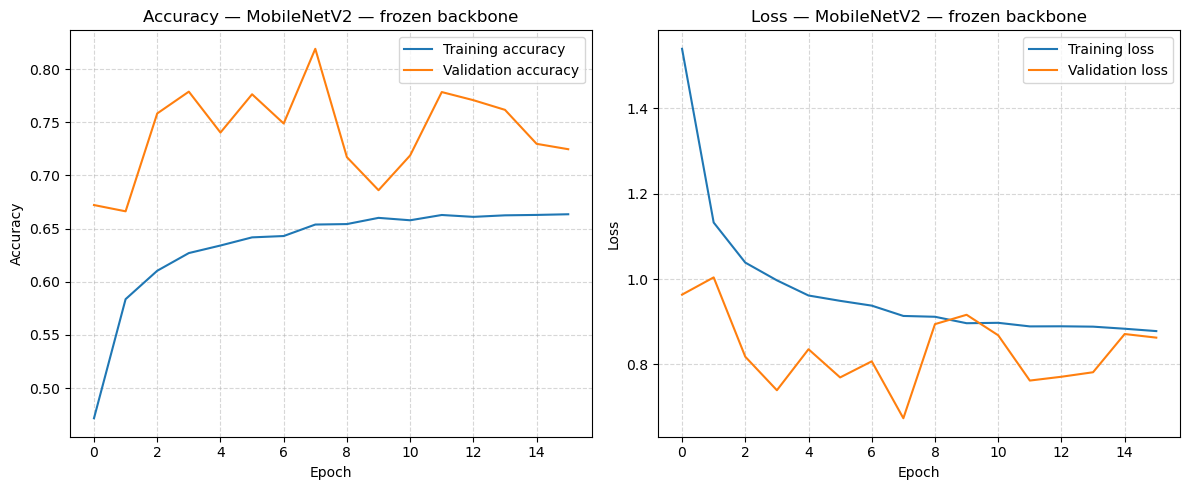

In [13]:
frozen_name = "MobileNetV2 — frozen backbone"

frozen_checkpoint = (
    CHECKPOINT_DIR
    / "mobilenetv2_frozen.weights.h5"
)

history_frozen = model.fit(
    X_train,
    y_train_categorical,
    epochs=FROZEN_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(
        X_validation,
        y_validation_categorical,
    ),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        frozen_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    shuffle=True,
    verbose=1,
)

plot_training_history(
    history_frozen,
    frozen_name,
)

## Fine-tuning

The best frozen-backbone checkpoint is restored before fine-tuning. Only the final MobileNetV2 layers are unfrozen, while all BatchNormalization layers remain frozen. The backbone continues to run in inference mode.

In [14]:
model.load_weights(frozen_checkpoint)

fine_tune_from = configure_fine_tuning(
    base_model,
    FINE_TUNE_LAYERS,
)

fine_tuned_trainable_parameters = int(
    sum(
        np.prod(weight.shape)
        for weight in model.trainable_weights
    )
)

compile_model(
    model,
    learning_rate=FINE_TUNE_LEARNING_RATE,
)

print(
    f"Fine-tuning the final {FINE_TUNE_LAYERS} "
    "MobileNetV2 layers."
)
print(
    "First trainable backbone layer: "
    f"{base_model.layers[fine_tune_from].name}"
)
print(
    "Trainable parameters during fine-tuning: "
    f"{fine_tuned_trainable_parameters:,}"
)

Fine-tuning the final 30 MobileNetV2 layers.
First trainable backbone layer: block_13_project_BN
Trainable parameters during fine-tuning: 1,522,249


Epoch 1/30
125/125 [==============================] - ETA: 0s - loss: 0.8852 - accuracy: 0.6626 — val_macro_f1: 0.5851 — val_balanced_accuracy: 0.6458
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 11s 76ms/step - loss: 0.8852 - accuracy: 0.6626 - val_loss: 0.7513 - val_accuracy: 0.7415 - val_macro_f1: 0.5851 - val_balanced_accuracy: 0.6458 - lr: 1.0000e-05
Epoch 2/30
125/125 [==============================] - 9s 69ms/step - loss: 0.8419 - accuracy: 0.6830 - val_loss: 0.8050 - val_accuracy: 0.7301 - val_macro_f1: 0.5687 - val_balanced_accuracy: 0.6684 - lr: 1.0000e-05
Epoch 3/30
125/125 [==============================] - ETA: 0s - loss: 0.8223 - accuracy: 0.6876 — val_macro_f1: 0.5911 — val_balanced_accuracy: 0.6630
Saved new best Macro F1 checkpoint at epoch 3.
125/125 [==============================] - 9s 70ms/step - loss: 0.8223 - accuracy: 0.6876 - val_loss: 0.6992 - val_accuracy: 0.7799 - val_macro_f1: 0.5911 - val_balanced_accuracy: 0.66

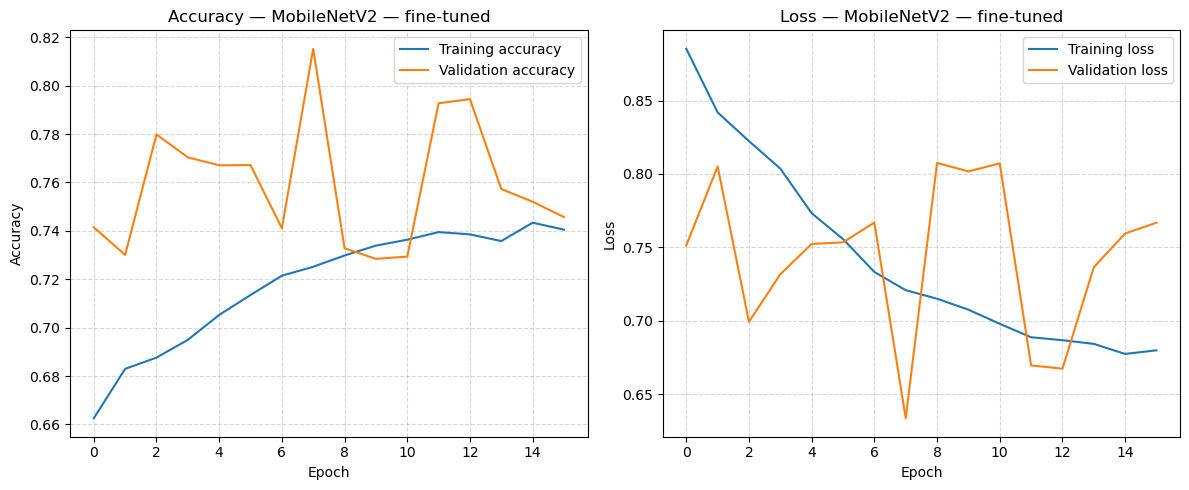

In [15]:
fine_tuned_name = "MobileNetV2 — fine-tuned"

fine_tuned_checkpoint = (
    CHECKPOINT_DIR
    / "mobilenetv2_fine_tuned.weights.h5"
)

history_fine_tuned = model.fit(
    X_train,
    y_train_categorical,
    epochs=FINE_TUNE_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(
        X_validation,
        y_validation_categorical,
    ),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        fine_tuned_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    shuffle=True,
    verbose=1,
)

plot_training_history(
    history_fine_tuned,
    fine_tuned_name,
)

## Validation-based model selection

The frozen and fine-tuned checkpoints are evaluated on the same validation partition. Macro F1 is the primary selection metric and balanced accuracy is the secondary metric.

Each checkpoint is loaded into a freshly reconstructed model with the same trainable-layer configuration used when that checkpoint was saved. This avoids weight-order incompatibilities between frozen and fine-tuned nested models.

In [16]:
checkpoint_specs = {
    frozen_name: {
        "checkpoint": frozen_checkpoint,
        "fine_tuned": False,
    },
    fine_tuned_name: {
        "checkpoint": fine_tuned_checkpoint,
        "fine_tuned": True,
    },
}

checkpoint_paths = {
    model_name: specification["checkpoint"]
    for model_name, specification in checkpoint_specs.items()
}

validation_records = []
validation_reports = {}
validation_confusion_matrices = {}


def build_model_for_checkpoint(fine_tuned):
    candidate_model, candidate_base_model = (
        build_mobilenetv2_model(
            num_classes=num_classes,
            input_shape=(*TARGET_SHAPE, 1),
            weights=None,
        )
    )

    if fine_tuned:
        configure_fine_tuning(
            candidate_base_model,
            FINE_TUNE_LAYERS,
        )
    else:
        candidate_base_model.trainable = False

    return candidate_model, candidate_base_model


for model_name, specification in checkpoint_specs.items():
    checkpoint_path = specification["checkpoint"]

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}"
        )

    candidate_model, candidate_base_model = (
        build_model_for_checkpoint(
            fine_tuned=specification["fine_tuned"]
        )
    )

    candidate_model.load_weights(checkpoint_path)

    metrics, report, matrix, _ = evaluate_classifier(
        candidate_model,
        X_validation,
        y_validation,
        class_names,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    validation_records.append(
        {
            "Model": model_name,
            **metrics,
        }
    )

    validation_reports[model_name] = report
    validation_confusion_matrices[model_name] = matrix

    del candidate_model
    del candidate_base_model


validation_df = (
    pd.DataFrame(validation_records)
    .set_index("Model")
    .sort_values(
        ["Macro F1", "Balanced Accuracy"],
        ascending=False,
    )
)

display(
    validation_df.style.format(
        {
            column: "{:.2%}"
            for column in validation_df.columns
        }
    )
)

selected_model_name = validation_df.index[0]
selected_specification = checkpoint_specs[
    selected_model_name
]
selected_checkpoint = selected_specification[
    "checkpoint"
]
selected_is_fine_tuned = bool(
    selected_specification["fine_tuned"]
)

print(
    "Model selected from validation metrics: "
    f"{selected_model_name}"
)

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
MobileNetV2 — fine-tuned,81.52%,67.99%,57.82%,67.99%,60.53%
MobileNetV2 — frozen backbone,81.91%,63.69%,57.18%,63.69%,58.39%


Model selected from validation metrics: MobileNetV2 — fine-tuned


In [ ]:
model, base_model = build_model_for_checkpoint(
    fine_tuned=selected_is_fine_tuned
)

model.load_weights(selected_checkpoint)

print(
    "Selected checkpoint loaded successfully: "
    f"{selected_checkpoint}"
)

## Final evaluation on the large test set

The test set is evaluated once, after selecting the checkpoint on validation data.

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
MobileNetV2 — fine-tuned,81.03%,67.14%,56.80%,67.14%,59.46%


,precision,recall,f1-score,support
center,0.405,0.682,0.508,859
donut,0.674,0.559,0.611,111
edge-loc,0.154,0.562,0.242,1038
edge-ring,0.908,0.928,0.918,1936
loc,0.183,0.400,0.251,718
near-full,0.966,0.933,0.949,30
none,0.974,0.830,0.896,29486
random,0.670,0.902,0.768,173
scratch,0.179,0.247,0.207,239
accuracy,0.810,0.810,0.810,1


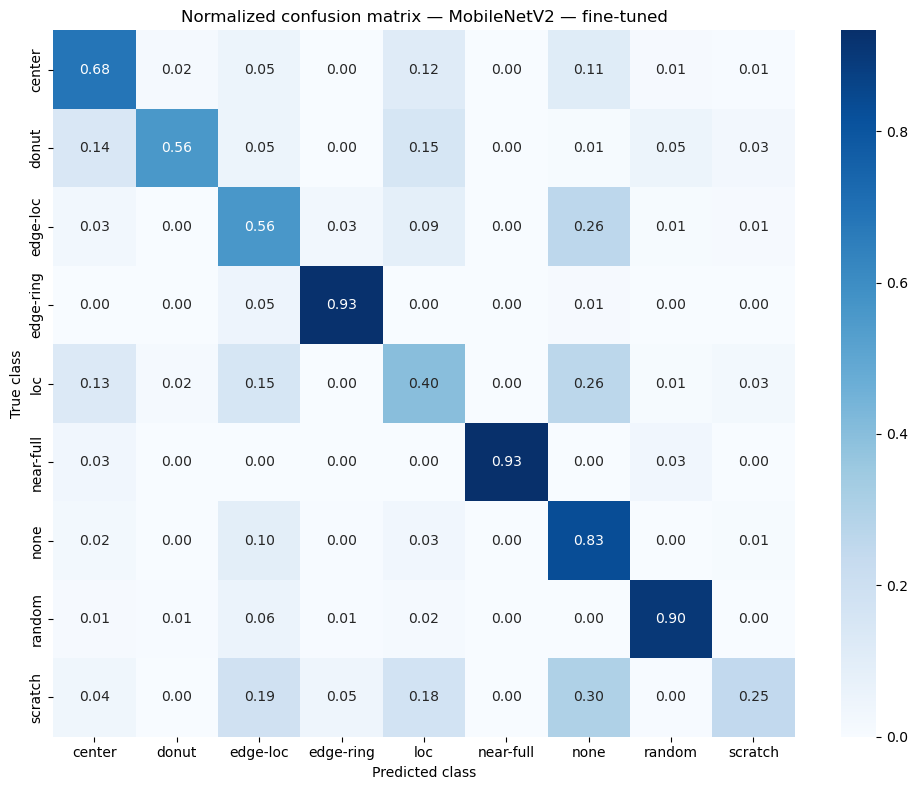

In [18]:
test_metrics, test_report, test_matrix, test_predictions = (
    evaluate_classifier(
        model,
        X_test,
        y_test,
        class_names,
        batch_size=PREDICTION_BATCH_SIZE,
    )
)

test_df = pd.DataFrame(
    [
        {
            "Model": selected_model_name,
            **test_metrics,
        }
    ]
).set_index("Model")

display(
    test_df.style.format(
        {
            column: "{:.2%}"
            for column in test_df.columns
        }
    )
)

display(
    test_report.loc[
        list(class_names)
        + ["accuracy", "macro avg", "weighted avg"]
    ].style.format(
        {
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1-score": "{:.3f}",
            "support": "{:.0f}",
        }
    )
)

plot_confusion_matrix(
    test_matrix,
    class_names,
    title=(
        "Normalized confusion matrix — "
        f"{selected_model_name}"
    ),
    normalize=True,
)

## Saved outputs

The output directory contains the fixed split, validation comparison, selected-model test results, classification report, metadata, checkpoints, and audit information.

In [ ]:
np.savez_compressed(
    OUTPUT_DIR / "split_indices.npz",
    train_pool_indices=train_pool_indices,
    train_indices=train_indices,
    validation_indices=validation_indices,
    test_indices=test_indices,
)

validation_df.to_csv(
    OUTPUT_DIR / "validation_results.csv"
)

test_df.to_csv(
    OUTPUT_DIR / "large_test_results.csv"
)

test_report.to_csv(
    OUTPUT_DIR / "selected_model_classification_report.csv"
)

split_distribution.to_csv(
    OUTPUT_DIR / "split_distribution.csv"
)

selected_fine_tuned_layers = (
    FINE_TUNE_LAYERS
    if selected_is_fine_tuned
    else 0
)

architecture_metadata = pd.DataFrame(
    {
        "Architecture": ["MobileNetV2"],
        "Pretrained weights": [MOBILENET_WEIGHTS],
        "Input shape": [str((*TARGET_SHAPE, 1))],
        "Backbone input shape": [str((*TARGET_SHAPE, 3))],
        "Total parameters": [model.count_params()],
        "Fine-tuned backbone layers": [
            selected_fine_tuned_layers
        ],
        "BatchNormalization frozen": [True],
        "Training cap per class": [MAX_SAMPLES_PER_CLASS],
        "Batch size": [BATCH_SIZE],
        "Seed": [SEED],
        "Selected model": [selected_model_name],
    }
)

architecture_metadata.to_csv(
    OUTPUT_DIR / "architecture_metadata.csv",
    index=False,
)

print(f"Saved outputs under: {OUTPUT_DIR}")

## Technical audit

The audit records the dataset content, split hashes, selected checkpoint, model parameters, and final metrics.

In [ ]:
def repository_relative_path(path):
    return (
        Path(path)
        .resolve()
        .relative_to(REPO_ROOT.resolve())
        .as_posix()
    )


checkpoint_records = []

for model_name, checkpoint_path in checkpoint_paths.items():
    checkpoint_records.append(
        {
            "Model": model_name,
            "Repository path": repository_relative_path(
                checkpoint_path
            ),
            "Exists": checkpoint_path.exists(),
            "SHA256": sha256_file(checkpoint_path),
        }
    )

checkpoint_audit_df = (
    pd.DataFrame(checkpoint_records)
    .set_index("Model")
)

display(checkpoint_audit_df)

if not checkpoint_audit_df["Exists"].all():
    raise FileNotFoundError(
        "One or more MobileNetV2 checkpoints are missing."
    )

if not checkpoint_audit_df[
    "Repository path"
].is_unique:
    raise AssertionError(
        "Multiple MobileNetV2 configurations point to "
        "the same checkpoint path."
    )

audit_data = {
    "model_family": "MOBILENETV2",
    "dataset": {
        "path": repository_relative_path(DATASET_PATH),
        "exists": DATASET_PATH.exists(),
        "sha256": dataset_sha256,
        "number_of_rows": int(len(df)),
    },
    "splits": {
        "train": {
            "size": int(len(train_indices)),
            "sha256": sha256_array(train_indices),
        },
        "validation": {
            "size": int(len(validation_indices)),
            "sha256": sha256_array(validation_indices),
        },
        "test": {
            "size": int(len(test_indices)),
            "sha256": sha256_array(test_indices),
        },
    },
    "selected_model": {
        "name": selected_model_name,
        "checkpoint": repository_relative_path(
            selected_checkpoint
        ),
        "total_parameters": int(model.count_params()),
        "fine_tuned_backbone_layers": int(
            selected_fine_tuned_layers
        ),
        "validation_metrics": {
            metric: float(value)
            for metric, value in validation_df.loc[
                selected_model_name
            ].items()
        },
        "test_metrics": {
            metric: float(value)
            for metric, value in test_df.loc[
                selected_model_name
            ].items()
        },
    },
    "training": {
        "pretrained_weights": MOBILENET_WEIGHTS,
        "head_learning_rate": HEAD_LEARNING_RATE,
        "fine_tune_learning_rate": FINE_TUNE_LEARNING_RATE,
        "frozen_epochs": FROZEN_EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "safe_flips_only": True,
        "class_weights": False,
    },
    "checkpoint_paths_are_unique": True,
}

audit_path = (
    AUDIT_DIR
    / "mobilenetv2_audit.json"
)

with audit_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        audit_data,
        file,
        indent=2,
    )

checkpoint_audit_df.to_csv(
    AUDIT_DIR
    / "mobilenetv2_checkpoints.csv"
)

print(f"Audit saved to: {audit_path}")